[INFO] 환경 설정 완료
[INFO] 총 데이터 수: 200개
[INFO] 컬럼: ['id', 'category', 'difficulty', 'source', 'question', 'ground_truth', 'legal_basis', 'risk_level', 'notes']

[INFO] 결측치 현황:
id              0
category        0
difficulty      0
source          0
question        0
ground_truth    0
legal_basis     0
risk_level      0
notes           0
dtype: int64
[Table 1] 카테고리별 문항 분포
 category  기본  심화  합계
  보호결정·국적  16  11  27
       가사  15   7  22
  복지·정착지원  18   2  20
       형사  16   3  19
       민사  14   3  17
       행정  10   2  12
  취업·직업훈련  10   0  10
   정착금·주거   8   2  10
보호의 변경·종료   5   4   9
    교육·취업   8   1   9
    의료·복지   7   1   8
     법률구조   7   0   7
       교육   6   0   6
     개인정보   4   1   5
     지역적응   4   0   4
     신변보호   3   1   4
     자격인정   4   0   4
       고용   3   0   3
   무연고청소년   1   1   2
       영농   2   0   2
       합계 161  39 200
[Table 2] Risk Level × Difficulty 교차표
difficulty   기본  심화   합계
risk_level              
high         39  16   55
medium       33  14   47
low     

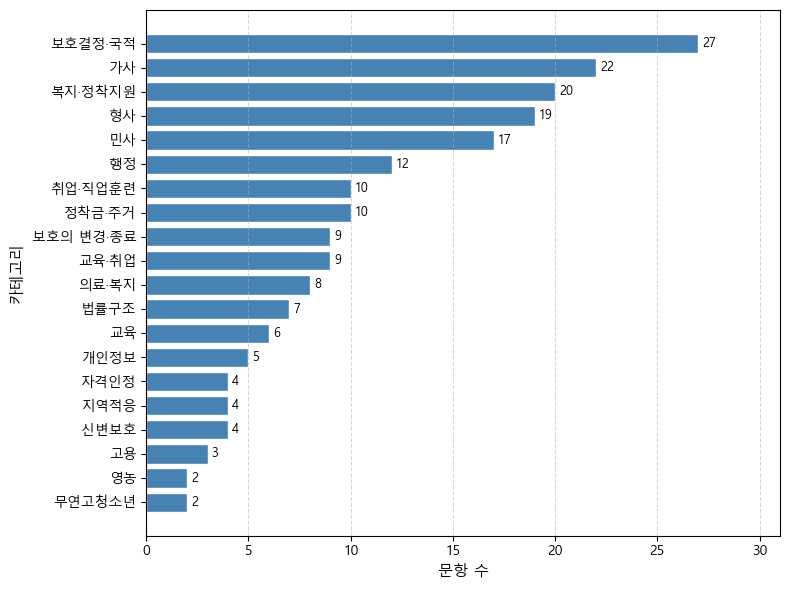

[Figure 1] 저장 완료


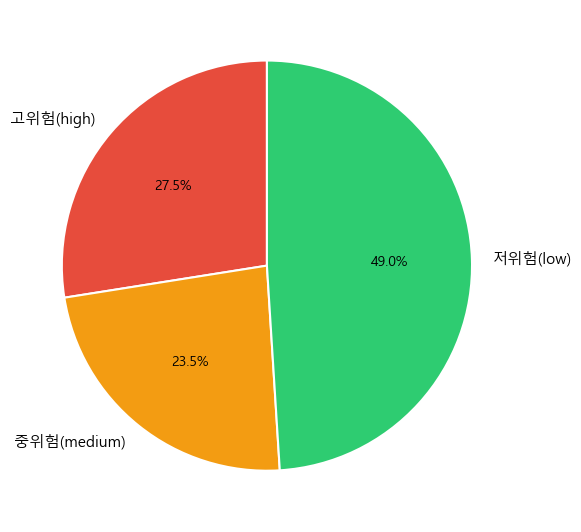

[Figure 2] 저장 완료


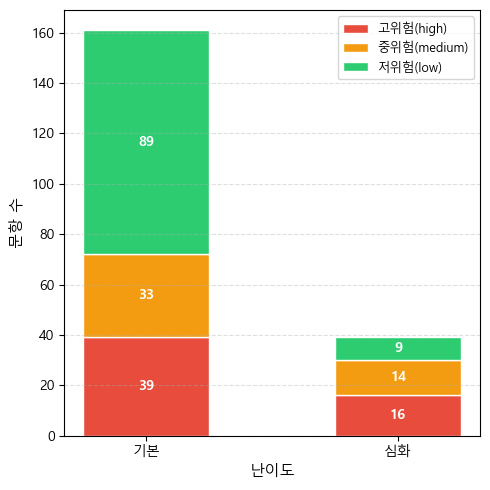

[Figure 3] 저장 완료


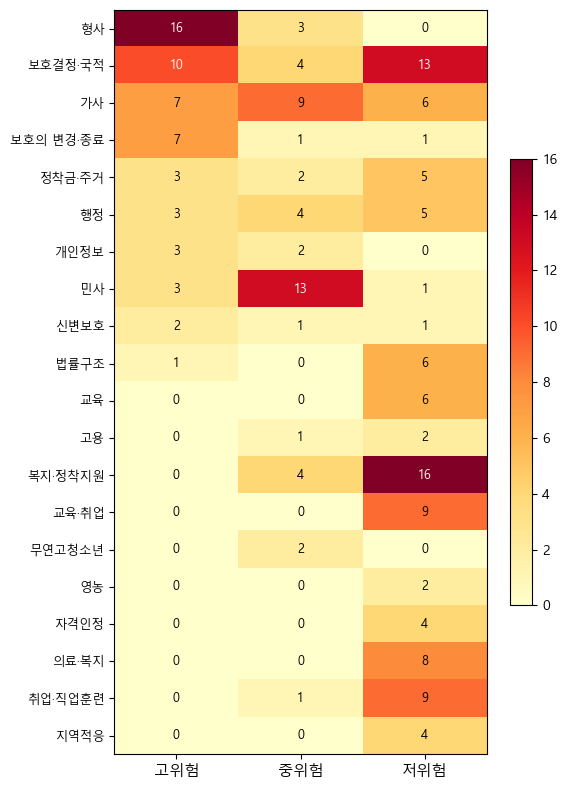

[Figure 4] 저장 완료
01_data_analysis 완료 요약
총 문항 수       : 200개
카테고리 수      : 20개
고위험(high) 수  : 55개
중위험(medium) 수: 47개
저위험(low) 수   : 98개
기본 난이도 수   : 161개
심화 난이도 수   : 39개

[저장 완료]
  tables/ : table1~3.csv
  figures/: figure1~4.png (DPI 600)


In [1]:
# %%
# =============================================================================
# 셀 1. 라이브러리 및 환경 설정
# =============================================================================
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# 한글 폰트 설정 (Windows: 맑은 고딕)
rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

# 저장 경로 생성
os.makedirs('../results/tables', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

DPI = 600  # 논문용 해상도

print("[INFO] 환경 설정 완료")


# %%
# =============================================================================
# 셀 2. 데이터 로드 및 통합
# =============================================================================
with open('../data/nkrefugee_qa_1_100.json', 'r', encoding='utf-8') as f:
    qa_1_100 = json.load(f)

with open('../data/nkrefugee_qa_101_200.json', 'r', encoding='utf-8') as f:
    qa_101_200 = json.load(f)

qa_all = qa_1_100 + qa_101_200
df = pd.DataFrame(qa_all)

# 기본 확인
print(f"[INFO] 총 데이터 수: {len(df)}개")
print(f"[INFO] 컬럼: {df.columns.tolist()}")
print(f"\n[INFO] 결측치 현황:")
print(df.isnull().sum())


# %%
# =============================================================================
# 셀 3. Table 1 — 카테고리별 문항 분포 (논문 삽입용 CSV)
# =============================================================================
# 카테고리별 × difficulty × risk_level 집계
tbl_cat = (
    df.groupby(['category', 'difficulty', 'risk_level'])
      .size()
      .reset_index(name='문항수')
)

# 피벗: 행=카테고리, 열=difficulty
tbl_pivot = df.pivot_table(
    index='category',
    columns='difficulty',
    values='id',
    aggfunc='count',
    fill_value=0
).reset_index()
tbl_pivot.columns.name = None
tbl_pivot['합계'] = tbl_pivot.select_dtypes(include='number').sum(axis=1)
tbl_pivot = tbl_pivot.sort_values('합계', ascending=False).reset_index(drop=True)
tbl_pivot.index += 1  # 1부터 시작

# 합계 행 추가
total_row = pd.DataFrame(
    [['합계'] + tbl_pivot.select_dtypes(include='number').sum().tolist()],
    columns=tbl_pivot.columns
)
tbl_final = pd.concat([tbl_pivot, total_row], ignore_index=True)

# 저장
tbl_final.to_csv('../results/tables/table1_category_distribution.csv',
                 index=False, encoding='utf-8-sig')
print("[Table 1] 카테고리별 문항 분포")
print(tbl_final.to_string(index=False))


# %%
# =============================================================================
# 셀 4. Table 2 — Risk Level × Difficulty 교차표 (논문 삽입용 CSV)
# =============================================================================
tbl_cross = pd.crosstab(
    df['risk_level'],
    df['difficulty'],
    margins=True,
    margins_name='합계'
)
# 순서 정렬
risk_order = ['high', 'medium', 'low', '합계']
tbl_cross = tbl_cross.reindex(risk_order)

tbl_cross.to_csv('../results/tables/table2_risk_difficulty_crosstab.csv',
                 encoding='utf-8-sig')
print("[Table 2] Risk Level × Difficulty 교차표")
print(tbl_cross)


# %%
# =============================================================================
# 셀 5. Table 3 — 법적 근거(source) 유형별 분포 (논문 삽입용 CSV)
# =============================================================================
# source 필드에서 주요 출처 분류
def classify_source(s):
    if '탈북민지원법' in str(s):
        return '탈북민지원법'
    elif '서울지방변호사회' in str(s):
        return '서울지방변호사회 매뉴얼'
    elif '민법' in str(s) or '형법' in str(s) or '형사소송법' in str(s):
        return '일반 민·형사법'
    elif '근로' in str(s) or '고용' in str(s):
        return '노동·고용법'
    else:
        return '기타'

df['source_type'] = df['source'].apply(classify_source)

tbl_source = (
    df.groupby('source_type')
      .agg(문항수=('id', 'count'))
      .assign(비율=lambda x: (x['문항수'] / len(df) * 100).round(1))
      .sort_values('문항수', ascending=False)
      .reset_index()
)

tbl_source.to_csv('../results/tables/table3_source_distribution.csv',
                  index=False, encoding='utf-8-sig')
print("[Table 3] 법적 근거 유형별 분포")
print(tbl_source.to_string(index=False))


# %%
# =============================================================================
# 셀 6. Figure 1 — 카테고리별 문항 수 (수평 막대 그래프)
# =============================================================================
cat_counts = df['category'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')

# 값 레이블
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('문항 수', fontsize=11)
ax.set_ylabel('카테고리', fontsize=11)
ax.set_xlim(0, cat_counts.max() + 4)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../results/figures/figure1_category_distribution.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("[Figure 1] 저장 완료")


# %%
# =============================================================================
# 셀 7. Figure 2 — Risk Level 분포 (파이 차트)
# =============================================================================
risk_counts = df['risk_level'].value_counts()
risk_order  = ['high', 'medium', 'low']
risk_counts = risk_counts.reindex(risk_order)
colors      = ['#e74c3c', '#f39c12', '#2ecc71']
labels_kr   = ['고위험(high)', '중위험(medium)', '저위험(low)']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    risk_counts.values,
    labels=labels_kr,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in texts:
    t.set_fontsize(11)
for t in autotexts:
    t.set_fontsize(10)

plt.tight_layout()
plt.savefig('../results/figures/figure2_risk_distribution.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("[Figure 2] 저장 완료")


# %%
# =============================================================================
# 셀 8. Figure 3 — Difficulty × Risk Level 누적 막대 그래프
# =============================================================================
cross = pd.crosstab(df['difficulty'], df['risk_level'])
cross = cross.reindex(columns=['high', 'medium', 'low'])
diff_order = ['기본', '심화']
# 영문 difficulty가 있을 경우 대비
cross.index = cross.index.map(lambda x: x if x in diff_order else x)

colors_bar = ['#e74c3c', '#f39c12', '#2ecc71']
labels_bar = ['고위험(high)', '중위험(medium)', '저위험(low)']

fig, ax = plt.subplots(figsize=(5, 5))
bottom = np.zeros(len(cross))
for col, color, label in zip(cross.columns, colors_bar, labels_bar):
    vals = cross[col].values
    ax.bar(cross.index, vals, bottom=bottom, color=color,
           label=label, edgecolor='white', width=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(i, b + v / 2, str(v), ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
    bottom += vals

ax.set_xlabel('난이도', fontsize=11)
ax.set_ylabel('문항 수', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/figure3_difficulty_risk_stacked.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("[Figure 3] 저장 완료")


# %%
# =============================================================================
# 셀 9. Figure 4 — 카테고리 × Risk Level 히트맵
# =============================================================================
heat = pd.crosstab(df['category'], df['risk_level'])
heat = heat.reindex(columns=['high', 'medium', 'low'], fill_value=0)
heat = heat.sort_values('high', ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(['고위험', '중위험', '저위험'], fontsize=11)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=9)

# 셀 값 표시
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        val = heat.values[i, j]
        color = 'white' if val > heat.values.max() * 0.6 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=9, color=color)

plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.savefig('../results/figures/figure4_category_risk_heatmap.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("[Figure 4] 저장 완료")


# %%
# =============================================================================
# 셀 10. 최종 요약 출력
# =============================================================================
print("=" * 50)
print("01_data_analysis 완료 요약")
print("=" * 50)
print(f"총 문항 수       : {len(df)}개")
print(f"카테고리 수      : {df['category'].nunique()}개")
print(f"고위험(high) 수  : {(df['risk_level']=='high').sum()}개")
print(f"중위험(medium) 수: {(df['risk_level']=='medium').sum()}개")
print(f"저위험(low) 수   : {(df['risk_level']=='low').sum()}개")
print(f"기본 난이도 수   : {(df['difficulty']=='기본').sum()}개")
print(f"심화 난이도 수   : {(df['difficulty']=='심화').sum()}개")
print()
print("[저장 완료]")
print("  tables/ : table1~3.csv")
print("  figures/: figure1~4.png (DPI 600)")